# PCE Metamodeling for Heat Tranfer Problems

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from UQpy.distributions import Uniform, Normal, JointIndependent #, Lognormal
from UQpy.distributions.collection.Lognormal import Lognormal
from UQpy.surrogates import *

/home/wmpjrufg/Documents/ic_victor/env/lib/python3.12/site-packages/UQpy/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ================= FKML: núcleo matemático =================
def _phi(u, lam):
    # Trata lam -> 0 por continuidade: (u^lam - 1)/lam -> ln(u)
    return np.where(np.isclose(lam, 0.0), np.log(u), (u**lam - 1.0)/lam)

def gld_fkml_quantile(u, l1, l2, l3, l4):
    u = np.clip(u, 1e-12, 1-1e-12)
    return l1 + ( _phi(u, l3) - _phi(1-u, l4) ) / l2

def gld_fkml_qprime(u, l2, l3, l4):
    # Q'(u) = (u^(l3-1) + (1-u)^(l4-1)) / l2, com limites log quando lam≈0
    u = np.clip(u, 1e-12, 1-1e-12)
    term1 = np.where(np.isclose(l3, 0.0), 1.0/u, u**(l3 - 1.0))
    term2 = np.where(np.isclose(l4, 0.0), 1.0/(1.0 - u), (1.0 - u)**(l4 - 1.0))
    return (term1 + term2) / l2

# Newton estável para resolver x = Q(u)
def _solve_u_for_x(x, l1, l2, l3, l4, maxit=60, tol=1e-10):
    x = np.atleast_1d(x).astype(float)
    # chute inicial por ranking -> (0,1)
    ranks = (np.argsort(np.argsort(x)) + 0.5) / (len(x) + 1.0)
    u = np.clip(ranks, 1e-4, 1-1e-4)
    for _ in range(maxit):
        q  = gld_fkml_quantile(u, l1, l2, l3, l4)
        qp = gld_fkml_qprime(u, l2, l3, l4)
        step = (q - x)/np.maximum(qp, 1e-16)
        u_new = np.clip(u - step, 1e-8, 1-1e-8)
        if np.max(np.abs(u_new - u)) < tol:
            u = u_new
            break
        u = u_new
    return u

def gld_fkml_pdf(x, l1, l2, l3, l4):
    if l2 <= 0:
        return np.full_like(np.atleast_1d(x), 0.0, dtype=float)
    u  = _solve_u_for_x(x, l1, l2, l3, l4)
    qp = gld_fkml_qprime(u, l2, l3, l4)
    return 1.0/np.maximum(qp, 1e-300)

# ================= MLE com bounds e padronização =================
def _mad(x):
    med = np.median(x)
    return np.median(np.abs(x - med))

def fit_gld_fkml_mle(data, x0=None, bounds=None):
    data = np.asarray(data, dtype=float)
    # Padroniza para estabilizar a busca
    m, s = np.median(data), (1.4826*_mad(data) or np.std(data, ddof=1) or 1.0)
    z = (data - m)/s

    # inicialização
    if x0 is None:
        x0 = np.array([0.0, 1.0, 0.1, 0.1])  # l1≈0, l2≈1, leve assimetria

    # bounds: l2>0; restringe forma para evitar explosões numéricas
    if bounds is None:
        bounds = [(-np.inf, np.inf), (1e-4, np.inf), (-3.0, 3.0), (-3.0, 3.0)]

    def nll(params):
        l1, l2, l3, l4 = params
        if not np.isfinite(l1 + l2 + l3 + l4) or l2 <= 0:
            return np.inf
        f = gld_fkml_pdf(z, l1, l2, l3, l4)
        if np.any(f <= 0) or np.any(~np.isfinite(f)):
            return np.inf
        return -np.sum(np.log(f))

    res = minimize(nll, x0, method="L-BFGS-B", bounds=bounds)

    # desfaz padronização: Qx(u) = m + s * Qz(u)  => l1x = m + s*l1z ; l2x = l2z / s
    l1z, l2z, l3, l4 = res.x
    l1x = m + s*l1z
    l2x = l2z / s
    return (l1x, l2x, l3, l4), res

# ================= Plot APENAS da GLD =================
def plot_gld_only(lambdas, n_points=2000, quantile_trim=1e-3, qp_min=1e-8, ylim=None):
    l1, l2, l3, l4 = lambdas
    a = float(quantile_trim)
    u = np.linspace(a, 1.0 - a, n_points)
    x = gld_fkml_quantile(u, l1, l2, l3, l4)
    qp = gld_fkml_qprime(u, l2, l3, l4)

    mask = np.isfinite(x) & np.isfinite(qp) & (qp > qp_min)
    x, f = x[mask], (1.0/qp[mask])

    order = np.argsort(x)
    x, f = x[order], f[order]

    plt.figure()
    plt.plot(x, f, linewidth=2)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Densidade GLD–FKML")
    if ylim is not None:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()

In [3]:
z1_mu = 2.
z1_sc = 0.60
s = np.sqrt(np.log(1 + (z1_sc/z1_mu)**2))
scale = z1_mu / np.sqrt(1 + (z1_sc/z1_mu)**2)
print(s, scale)

0.293560379208524 1.9156525704423026


# Construção do metamodelo

In [4]:
r   = Lognormal(s=0.16, loc = 0., scale=4.94)
s   = Lognormal(s=0.30, loc = 0., scale=1.91)
r   = Normal(loc = 5., scale=0.8)
s   = Normal(loc = 2., scale=0.6)

marg = [r, s]

joint = JointIndependent(marginals=marg)

n_samples = 1000
xx = joint.rvs(n_samples)

y = []
for i in range(n_samples):
    n = 50
    df = {'r': [xx[i, 0]] * n, 's': [xx[i, 1]] * n}
    df = pd.DataFrame(df)
    z1aux = []
    z2aux = []
    for i in df.iterrows():
        z1_mu = 1.
        z1_sc = 0.028
        s = np.sqrt(np.log(1 + (z1_sc/z1_mu)**2))
        scale = z1_mu / np.sqrt(1 + (z1_sc/z1_mu)**2)
        z1aux.append(stats.lognorm.rvs(s=s, scale=scale, size=1)[0])
        z2_mu = 1.
        z2_sc = 0.096
        s = np.sqrt(np.log(1 + (z2_sc/z2_mu)**2))
        scale = z2_mu / np.sqrt(1 + (z2_sc/z2_mu)**2)
        z2aux.append(stats.lognorm.rvs(s=s, scale=scale, size=1)[0])
    df['z1'] = z1aux
    df['z2'] = z2aux
    df['g'] = df['r'] / df['z1'] - df['s'] * df['z2']
    lambdas, _ = fit_gld_fkml_mle(df['g'].values)
    y.append(lambdas)
    yy = np.array(y)

yy

array([[2.11820209, 4.7894736 , 0.32171446, 0.28785602],
       [1.33584248, 9.90021875, 0.16264966, 0.21948366],
       [4.83043168, 7.8944587 , 0.33464207, 0.21238438],
       ...,
       [3.46455232, 4.76342338, 0.7182966 , 0.38177834],
       [4.56702688, 3.42460039, 0.51539051, 0.49670361],
       [3.73575437, 4.49281762, 0.28232302, 0.2127584 ]])

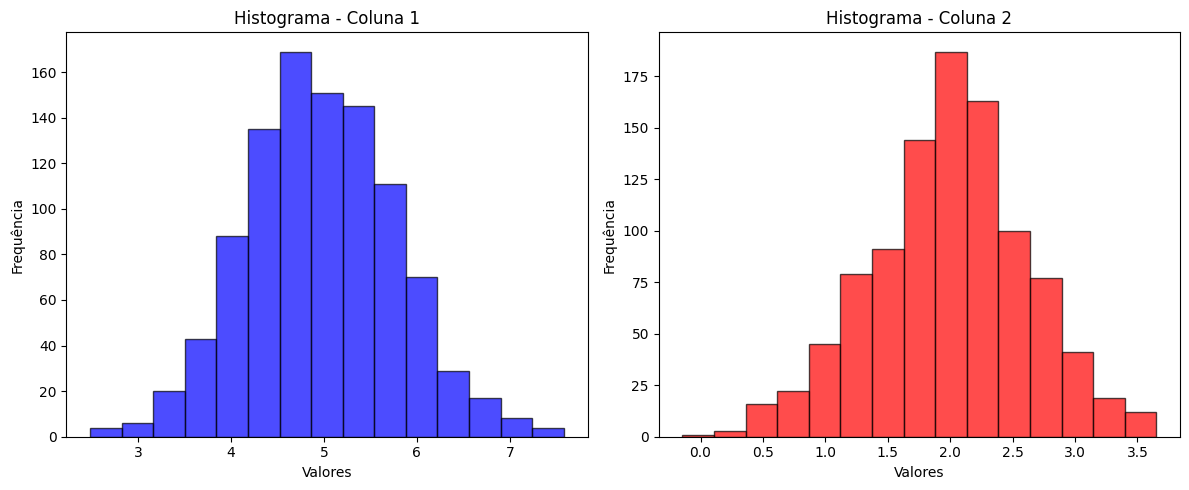

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Criar figura com dois subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histograma da primeira coluna
ax1.hist(xx[:, 0], bins=15, alpha=0.7, color='blue', edgecolor='black')
ax1.set_title('Histograma - Coluna 1')
ax1.set_xlabel('Valores')
ax1.set_ylabel('Frequência')

# Histograma da segunda coluna
ax2.hist(xx[:, 1], bins=15, alpha=0.7, color='red', edgecolor='black')
ax2.set_title('Histograma - Coluna 2')
ax2.set_xlabel('Valores')
ax2.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

In [6]:
max_degree = 8
polynomial_basis = TotalDegreeBasis(joint, max_degree)

least_squares = LeastSquareRegression()
pce_metamodel = PolynomialChaosExpansion(polynomial_basis=polynomial_basis, regression_method=least_squares)
pce_metamodel.fit(xx, yy)

In [7]:
print("xx shape:", xx.shape)  # (1000, 5)
print("yy shape:", yy.shape)  # (1000, 2000)

xx shape: (1000, 2)
yy shape: (1000, 4)


In [8]:
n_samples = 1000
x_val = joint.rvs(n_samples)

y = []
for i in range(n_samples):
    n = 50
    df = {'r': [xx[i, 0]] * n, 's': [xx[i, 1]] * n}
    df = pd.DataFrame(df)
    z1aux = []
    z2aux = []
    for i in df.iterrows():
        z1_mu = 1.
        z1_sc = 0.028
        s = np.sqrt(np.log(1 + (z1_sc/z1_mu)**2))
        scale = z1_mu / np.sqrt(1 + (z1_sc/z1_mu)**2)
        z1aux.append(stats.lognorm.rvs(s=s, scale=scale, size=1)[0])
        z2_mu = 1.
        z2_sc = 0.096
        s = np.sqrt(np.log(1 + (z2_sc/z2_mu)**2))
        scale = z2_mu / np.sqrt(1 + (z2_sc/z2_mu)**2)
        z2aux.append(stats.lognorm.rvs(s=s, scale=scale, size=1)[0])
    df['z1'] = z1aux
    df['z2'] = z2aux
    df['g'] = df['r'] / df['z1'] - df['s'] * df['z2']
    lambdas, _ = fit_gld_fkml_mle(df['g'].values)
    y.append(lambdas)
    yval = np.array(y)


y_val_pce = pce_metamodel.predict(x_val)

In [9]:
y_val_pce

array([[ 1.06725875e+06,  1.76410974e+06,  2.38729888e-01,
         7.43174074e-02],
       [-6.50365229e+05,  3.81326903e+05,  1.94735399e-01,
         2.99655641e-01],
       [-2.42215041e+05,  6.82018685e+06,  4.25124916e-01,
         5.31120427e-01],
       ...,
       [-4.63669398e+04,  5.01275356e+06,  4.63722316e-01,
         5.29060280e-01],
       [-1.44436619e+04,  2.77703764e+06,  4.19774836e-01,
         4.10813234e-01],
       [ 2.10238298e+04,  5.75818157e+06,  4.98780587e-01,
         5.56904090e-01]])

In [10]:
y_validation = pce_metamodel.predict(x_validation)

y_val_full = []
for i in range(len(x_validation)):
    y_val_full.append(analytical_solution(t, T0, L, x_validation[i,:]))
    y_val_resp = np.array(y_val_full)

NameError: name 'x_validation' is not defined

In [ ]:
y_val_test_p = y_validation.max(axis=1)
y_val_resp_p = y_val_resp.max(axis=1)

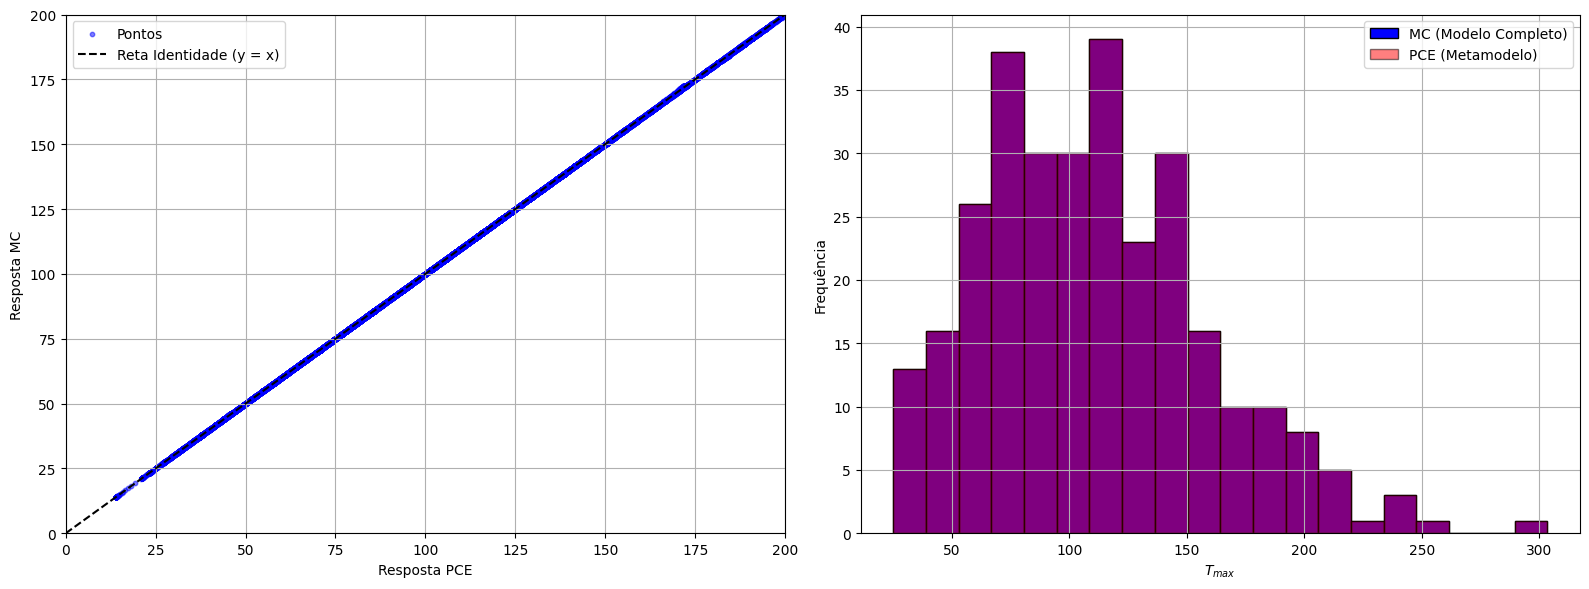

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  

axes[0].scatter(y_validation, y_val_resp, color='blue', alpha=0.5, s=10, label='Pontos')
axes[0].plot([0, 200], [0, 200], color='black', linestyle='--', label='Reta Identidade (y = x)')
axes[0].set_xlim(0, 200)
axes[0].set_ylim(0, 200)
axes[0].set_xlabel('Resposta PCE')
axes[0].set_ylabel('Resposta MC')
axes[0].legend()
axes[0].grid(True)

axes[1].hist(y_val_test_p, bins=20, color='blue', edgecolor='black', alpha=1, label='MC (Modelo Completo)')
axes[1].hist(y_val_resp_p, bins=20, color='red', edgecolor='black', alpha=0.5, label='PCE (Metamodelo)')
axes[1].set_xlabel('$T_{max}$')
axes[1].set_ylabel('Frequência')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

plt.show()